In [ ]:
 # 1. Install 7-Zip utility
!apt-get install -y -qq p7zip-full

import os
import glob
import subprocess

# Auto-detect any .7z file in the current Colab directory (/content)
archives_7z = glob.glob("/content/*.7z") + glob.glob("*.7z")

if not archives_7z:
    print("❌ No .7z file found! Please upload your .7z file in the Colab file explorer on the left.")
else:
    archive_path = archives_7z[0]
    extract_dir = "/content/extracted_data"
    os.makedirs(extract_dir, exist_ok=True)

    print(f"📦 Found archive: {archive_path}")
    print(f"🔄 Extracting to: {extract_dir} ...")

    # Extract using 7z command
    cmd = f'7z x "{archive_path}" -o"{extract_dir}" -y'
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if result.returncode == 0:
        print("✅ Extraction complete!")
    else:
        print("⚠️ Extraction output/error:\n", result.stdout, result.stderr)

# List extracted files
extracted_files = glob.glob(f"{extract_dir}/**/*", recursive=True)
tif_files = [f for f in extracted_files if f.lower().endswith(('.tif', '.tiff'))]
print(f"Found {len(tif_files)} .tif image(s) inside {extract_dir}.")

📦 Found archive: /content/01_Train_Val_Lookalike_mask.7z
🔄 Extracting to: /content/extracted_data ...
✅ Extraction complete!
Found 685 .tif image(s) inside /content/extracted_data.


      EXAMINING TIFF FILE: 00000.tif
 • Dimensions         : 2048 x 2048 (4,194,304 total pixels)
 • Data Type          : uint8
 • Min Value          : 0
 • Max Value          : 1
 • Unique Pixel Values: [0, 1]
 • Non-Zero Pixels    : 14,539 (0.3466% of image)
    - Value   0:  4,179,765 pixels
    - Value   1:     14,539 pixels



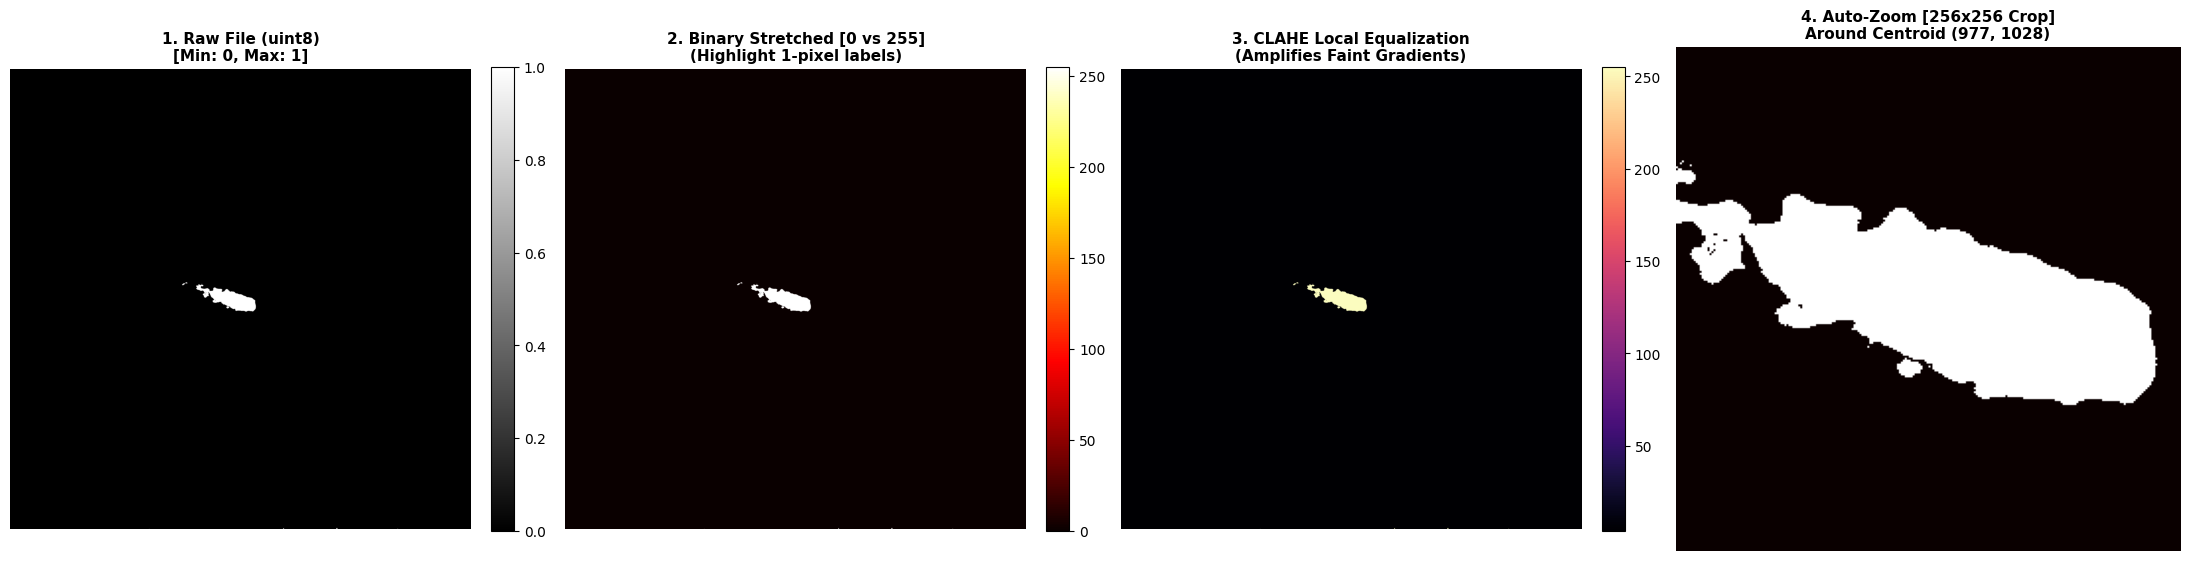

In [ ]:
# Install prerequisites if not already installed
!pip install -q rasterio matplotlib opencv-python numpy

import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2

def analyze_and_enhance_tif(tif_path="00000.tif"):
    if not os.path.exists(tif_path):
        # Check standard Colab / Kaggle upload locations
        candidates = [
            f"/content/{tif_path}",
            f"/content/extracted_data/Mask_lookalike/{tif_path}",
            f"/kaggle/working/{tif_path}"
        ]
        for c in candidates:
            if os.path.exists(c):
                tif_path = c
                break

    print(f"==================================================")
    print(f"      EXAMINING TIFF FILE: {os.path.basename(tif_path)}")
    print(f"==================================================")

    # 1. Read Raw TIFF using Rasterio
    with rasterio.open(tif_path) as src:
        raw_arr = src.read(1)
        meta = {
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "dtype": str(src.dtypes[0]),
            "crs": str(src.crs)
        }

    # 2. Pixel Statistics
    unique_vals, val_counts = np.unique(raw_arr, return_counts=True)
    min_v, max_v = np.min(raw_arr), np.max(raw_arr)
    non_zero_count = np.count_nonzero(raw_arr)
    total_pixels = raw_arr.size

    print(f" • Dimensions         : {meta['width']} x {meta['height']} ({total_pixels:,} total pixels)")
    print(f" • Data Type          : {meta['dtype']}")
    print(f" • Min Value          : {min_v}")
    print(f" • Max Value          : {max_v}")
    print(f" • Unique Pixel Values: {unique_vals.tolist()}")
    print(f" • Non-Zero Pixels    : {non_zero_count:,} ({(non_zero_count/total_pixels)*100:.4f}% of image)")

    for val, cnt in zip(unique_vals, val_counts):
        print(f"    - Value {val:>3}: {cnt:>10,} pixels")
    print(f"==================================================\n")

    # 3. Contrast & Enhancement Modes
    # Mode A: Normalized Linear Float
    norm_arr = raw_arr.astype(np.float32)
    if max_v > min_v:
        norm_arr = (norm_arr - min_v) / (max_v - min_v)

    # Mode B: Scaled Binary Mask (0 -> 0, 1 -> 255)
    binary_enhanced = (norm_arr * 255.0).astype(np.uint8)

    # Mode C: CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    clahe_enhanced = clahe.apply(binary_enhanced)

    # 4. Multi-Panel Rendering
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

    # Panel 1: Raw Image view
    im0 = axes[0].imshow(raw_arr, cmap='gray')
    axes[0].set_title(f"1. Raw File ({meta['dtype']})\n[Min: {min_v}, Max: {max_v}]", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Panel 2: Binary Scaled (0 to 255)
    im1 = axes[1].imshow(binary_enhanced, cmap='hot', vmin=0, vmax=255)
    axes[1].set_title("2. Binary Stretched [0 vs 255]\n(Highlight 1-pixel labels)", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel 3: CLAHE Adaptive Contrast
    im2 = axes[2].imshow(clahe_enhanced, cmap='magma')
    axes[2].set_title("3. CLAHE Local Equalization\n(Amplifies Faint Gradients)", fontsize=11, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # Panel 4: Auto-Zoom to Anomaly / Centroid
    if non_zero_count > 0:
        # Find coordinates of non-zero signal
        y_indices, x_indices = np.where(raw_arr > 0)
        cy, cx = int(np.mean(y_indices)), int(np.mean(x_indices))
        zoom_half_size = 128

        y1 = max(0, cy - zoom_half_size)
        y2 = min(meta['height'], cy + zoom_half_size)
        x1 = max(0, cx - zoom_half_size)
        x2 = min(meta['width'], cx + zoom_half_size)

        cropped_patch = binary_enhanced[y1:y2, x1:x2]
        axes[3].imshow(cropped_patch, cmap='hot', vmin=0, vmax=255)
        axes[3].set_title(f"4. Auto-Zoom [256x256 Crop]\nAround Centroid ({cx}, {cy})", fontsize=11, fontweight='bold')
    else:
        # If all-zero, show center crop
        cy, cx = meta['height'] // 2, meta['width'] // 2
        cropped_patch = binary_enhanced[cy-128:cy+128, cx-128:cx+128]
        axes[3].imshow(cropped_patch, cmap='hot', vmin=0, vmax=255)
        axes[3].set_title("4. Center Zoom [256x256]\n(Confirmed Solid 0 Grid)", fontsize=11, fontweight='bold')

    axes[3].axis('off')
    plt.tight_layout()
    plt.show()

# Run the function
analyze_and_enhance_tif("00000.tif")

In [ ]:
from google.colab import drive
import os

# Mount your 2 TB Google Drive
drive.mount('/content/drive')

# Install multi-stream downloader and 7zip
!apt-get update -qq && apt-get install -y -qq aria2 p7zip-full

# Create permanent folder in Google Drive
dataset_drive_dir = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"
os.makedirs(dataset_drive_dir, exist_ok=True)
print(f"Target Drive Directory: {dataset_drive_dir}")

Mounted at /content/drive
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.36.0-1_amd64.deb ...
Unpacking libaria2-0:amd64 (1.36.0-1) ...
Selecting previously unselected package aria2.
Preparing to unpack .../aria2_1.36.0-1_amd64.deb ...
Unpacking aria2 (1.36.0-1) ...
Setting up libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Setting up libaria2-0:amd64 (1.36.0-1) ...
Setting up aria2 (1.36.0-1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.14) ...


In [ ]:
import os
import subprocess
import sys
from google.colab import drive

# 1. Mount Google Drive if not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# 2. Install aria2
!apt-get update -qq && apt-get install -y -qq aria2 p7zip-full

# 3. Create target directory in your Google Drive
target_dir = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"
os.makedirs(target_dir, exist_ok=True)

# List of all dataset parts to download
downloads = [
    # --- PART 1: OIL SPILL ---
    {
        "name": "Part 1 Images (40.7 GB)",
        "url": "https://zenodo.org/records/8346860/files/01_Train_Val_Oil_Spill_images.7z?download=1",
        "output": "01_Train_Val_Oil_Spill_images.7z"
    },
    {
        "name": "Part 1 Masks (6.2 MB)",
        "url": "https://zenodo.org/records/8346860/files/01_Train_Val_Oil_Spill_mask.7z?download=1",
        "output": "01_Train_Val_Oil_Spill_mask.7z"
    },
    # --- PART 2: LOOKALIKES & NO-OIL ---
    {
        "name": "Part 2 Lookalike Images (23.0 GB)",
        "url": "https://zenodo.org/records/8253899/files/01_Train_Val_Lookalike_images.7z?download=1",
        "output": "01_Train_Val_Lookalike_images.7z"
    },
    {
        "name": "Part 2 Lookalike Masks (426 KB)",
        "url": "https://zenodo.org/records/8253899/files/01_Train_Val_Lookalike_mask.7z?download=1",
        "output": "01_Train_Val_Lookalike_mask.7z"
    },
    {
        "name": "Part 2 No-Oil Images (22.9 GB)",
        "url": "https://zenodo.org/records/8253899/files/01_Train_Val_No_Oil_Images.7z?download=1",
        "output": "01_Train_Val_No_Oil_Images.7z"
    },
    {
        "name": "Part 2 No-Oil Masks (416 KB)",
        "url": "https://zenodo.org/records/8253899/files/01_Train_Val_No_Oil_mask.7z?download=1",
        "output": "01_Train_Val_No_Oil_mask.7z"
    },
    # --- PART 3: TEST SET & GROUND TRUTH ---
    {
        "name": "Part 3 Test Benchmark (9.9 GB)",
        "url": "https://zenodo.org/records/13761290/files/02_Test_images_and_ground_truth.7z?download=1",
        "output": "02_Test_images_and_ground_truth.7z"
    }
]

print("==================================================================")
print("     STARTING MULTI-STREAM RESUMABLE DOWNLOAD (REAL-TIME LOGS)    ")
print(f"     Target: {target_dir}")
print("==================================================================\n")

for item in downloads:
    file_path = os.path.join(target_dir, item["output"])
    print(f"\n🚀 Downloading: {item['name']}")
    print(f"📁 Destination: {file_path}")

    # aria2c command with --summary-interval=2 to force live logs every 2 seconds
    cmd = [
        "aria2c",
        "-x", "16",
        "-s", "16",
        "-k", "2M",
        "-c", # Auto-resume broken downloads
        "--summary-interval=2",
        "--console-log-level=warn",
        item["url"],
        "-d", target_dir,
        "-o", item["output"]
    ]

    # Stream subprocess output line-by-line in real time
    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        universal_newlines=True,
        bufsize=1
    )

    for line in process.stdout:
        # Filter and display active progress status
        if "[" in line and "]" in line and "%" in line:
            sys.stdout.write(f"\r  📊 {line.strip()}")
            sys.stdout.flush()
        elif "Download complete" in line or "errorCode" in line or "Exception" in line:
            print(f"\n  ℹ️ {line.strip()}")

    process.wait()
    if process.returncode == 0:
        print(f"\n✅ Finished: {item['name']}")
    else:
        print(f"\n⚠️ Process exited with code {process.returncode} on {item['name']}")

print("\n🎉 ALL 5 DATASET ARCHIVES COMPLETED AND SAVED IN GOOGLE DRIVE!")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.36.0-1_amd64.deb ...
Unpacking libaria2-0:amd64 (1.36.0-1) ...
Selecting previously unselected package aria2.
Preparing to unpack .../aria2_1.36.0-1_amd64.deb ...
Unpacking aria2 (1.36.0-1) ...
Setting up libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Setting up libaria2-0:amd64 (1.36.0-1) ...
Setting up aria2 (1.36.0-1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.14) ...
/sbin/ldconfig.real: /usr/

In [ ]:
import os
import glob
from google.colab import drive

# 1. Verify Drive Mount
if not os.path.exists('/content/drive/MyDrive'):
    print("⚠️ Google Drive was not mounted. Mounting now...")
    drive.mount('/content/drive')
else:
    print("✅ Google Drive is mounted properly.")

# 2. Check Target Folder
target_dir = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"

if not os.path.exists(target_dir):
    print(f"❌ Target directory does not exist: {target_dir}")
    print("Existing folders in MyDrive:", os.listdir("/content/drive/MyDrive")[:10])
else:
    print(f"✅ Found directory: {target_dir}")
    folder_contents = os.listdir(target_dir)
    print(f"📁 Items inside {target_dir}:")
    for item in folder_contents:
        item_path = os.path.join(target_dir, item)
        if os.path.isdir(item_path):
            print(f"   📂 [DIR]  {item}")
        else:
            size_gb = os.path.getsize(item_path) / (1024**3)
            print(f"   📦 [FILE] {item} ({size_gb:.2f} GB)")

# 3. Check for .7z vs .tif files
zips_found = glob.glob(f"{target_dir}/*.7z")
tifs_found = glob.glob(f"{target_dir}/**/*.tif", recursive=True) + glob.glob(f"{target_dir}/**/*.tiff", recursive=True)

print("\n--- STATUS SUMMARY ---")
print(f" • Compressed (.7z) Archives Found : {len(zips_found)}")
print(f" • Extracted (.tif) Files Found     : {len(tifs_found)}")

if len(zips_found) > 0 and len(tifs_found) == 0:
    print("\n💡 DIAGNOSIS: The archives are downloaded, but they have NOT been extracted yet.")
    print("👉 Solution: Run the extraction cell below to extract sample scenes.")

✅ Google Drive is mounted properly.
✅ Found directory: /content/drive/MyDrive/SAR_OilSpill_Zenodo
📁 Items inside /content/drive/MyDrive/SAR_OilSpill_Zenodo:
   📦 [FILE] 01_Train_Val_Oil_Spill_images.7z (37.92 GB)
   📦 [FILE] 01_Train_Val_Oil_Spill_mask.7z (0.01 GB)
   📦 [FILE] 01_Train_Val_Lookalike_images.7z (21.41 GB)
   📦 [FILE] 01_Train_Val_Lookalike_mask.7z (0.00 GB)
   📦 [FILE] 01_Train_Val_No_Oil_Images.7z (21.36 GB)
   📦 [FILE] 01_Train_Val_No_Oil_mask.7z (0.00 GB)
   📦 [FILE] 02_Test_images_and_ground_truth.7z (9.18 GB)
   📂 [DIR]  raw_extracted
   📂 [DIR]  shards_webdataset

--- STATUS SUMMARY ---
 • Compressed (.7z) Archives Found : 7
 • Extracted (.tif) Files Found     : 6040


🔍 Searching for extracted files across Google Drive...
✅ Total TIFF files detected: 6040
 • Part 1 (Oil): 1200 images, 1200 masks
 • Part 2 (Lookalikes): 835 images, 835 masks
 • Part 2 (No-Oil): 685 images, 685 masks
 • Part 3 (Test Set): 900 total files


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


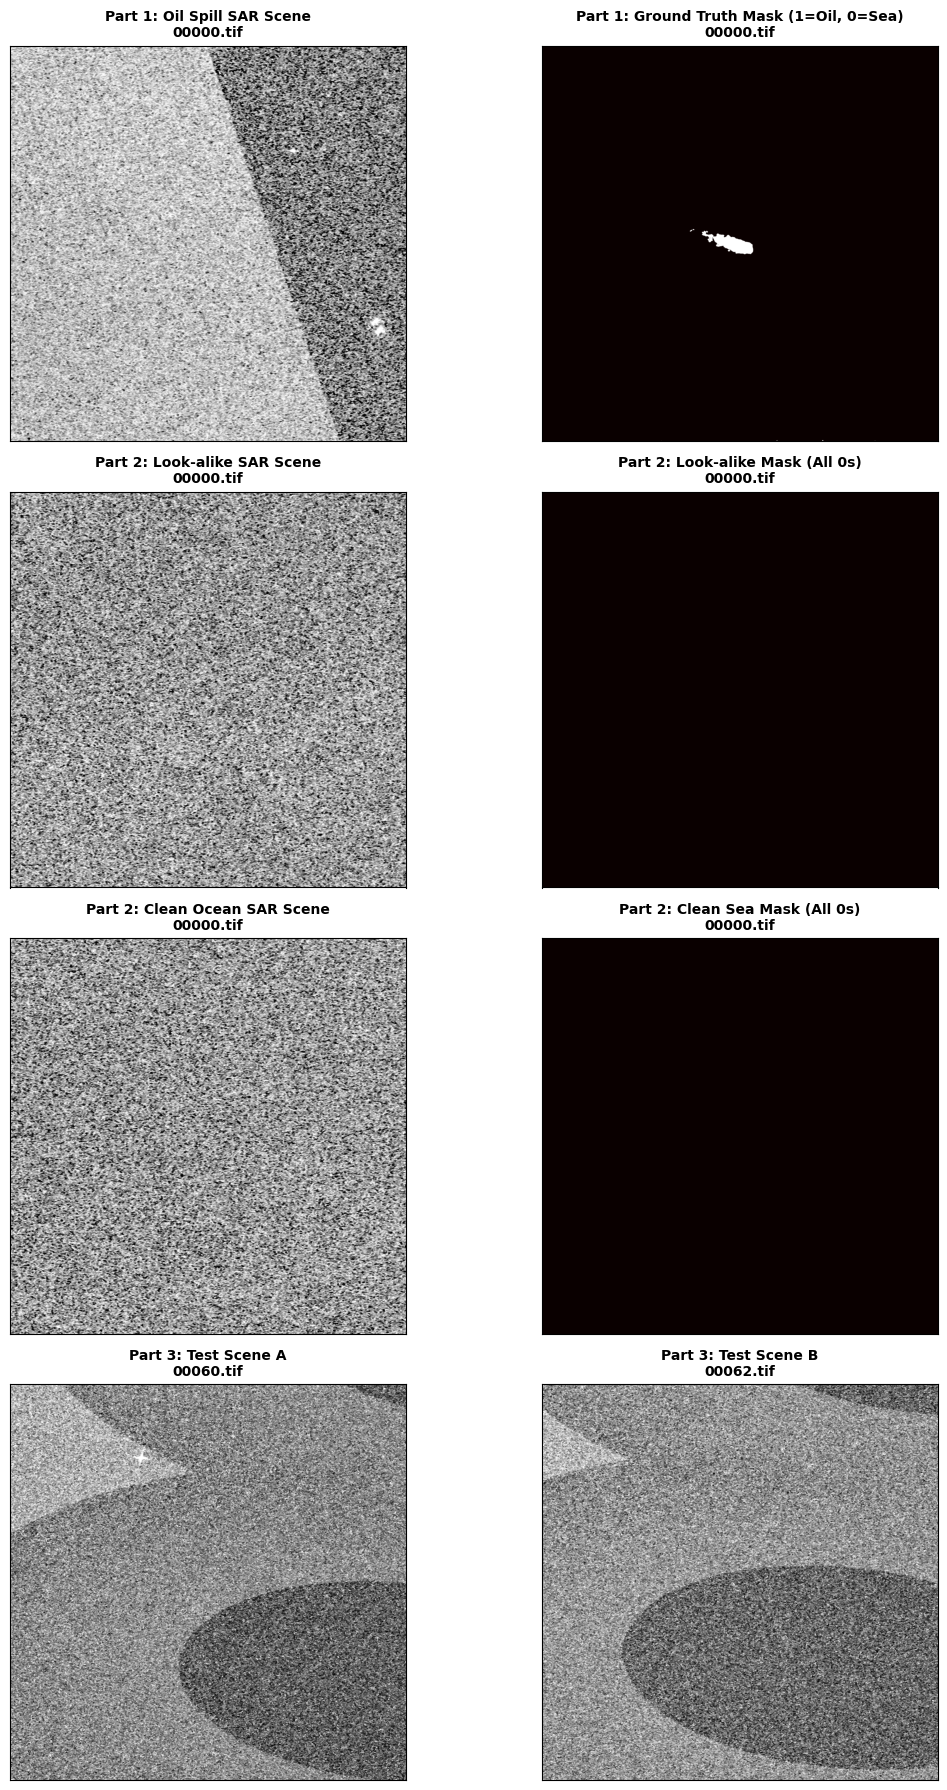

In [ ]:
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. Base search path in Google Drive
drive_root = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"

print("🔍 Searching for extracted files across Google Drive...")

# Find all TIFF files recursively
all_tifs = glob.glob(f"{drive_root}/**/*.tif", recursive=True) + \
           glob.glob(f"{drive_root}/**/*.TIF", recursive=True) + \
           glob.glob(f"{drive_root}/**/*.tiff", recursive=True)

print(f"✅ Total TIFF files detected: {len(all_tifs)}")

# 2. Categorize files by path keywords
def find_matching_pair(category_kw, mask_kw="mask"):
    imgs = [f for f in all_tifs if category_kw.lower() in f.lower() and mask_kw not in f.lower()]
    masks = [f for f in all_tifs if category_kw.lower() in f.lower() and mask_kw in f.lower()]
    return sorted(imgs), sorted(masks)

p1_imgs, p1_masks = find_matching_pair("part1")
if not p1_imgs:
    p1_imgs, p1_masks = find_matching_pair("oil_spill")

p2_la_imgs, p2_la_masks = find_matching_pair("lookalike")
p2_no_imgs, p2_no_masks = find_matching_pair("no_oil")
p3_test_files = [f for f in all_tifs if "part3" in f.lower() or "test" in f.lower()]

print(f" • Part 1 (Oil): {len(p1_imgs)} images, {len(p1_masks)} masks")
print(f" • Part 2 (Lookalikes): {len(p2_la_imgs)} images, {len(p2_la_masks)} masks")
print(f" • Part 2 (No-Oil): {len(p2_no_imgs)} images, {len(p2_no_masks)} masks")
print(f" • Part 3 (Test Set): {len(p3_test_files)} total files")

# 3. Helper to read and enhance contrast
def read_and_normalize(path, is_mask=False):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)

    if is_mask:
        # Scale binary mask 0/1 to 0/255 for visibility
        return (arr * 255.0).astype(np.uint8) if np.max(arr) <= 1.0 else arr.astype(np.uint8)
    else:
        # Contrast stretch SAR radar backscatter (2nd to 98th percentile)
        p2, p98 = np.percentile(arr, (2, 98))
        return np.clip((arr - p2) / (p98 - p2 + 1e-7), 0.0, 1.0)

# 4. Plotting Samples
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

pairs_to_plot = [
    (p1_imgs, p1_masks, "Part 1: Oil Spill SAR Scene", "Part 1: Ground Truth Mask (1=Oil, 0=Sea)"),
    (p2_la_imgs, p2_la_masks, "Part 2: Look-alike SAR Scene", "Part 2: Look-alike Mask (All 0s)"),
    (p2_no_imgs, p2_no_masks, "Part 2: Clean Ocean SAR Scene", "Part 2: Clean Sea Mask (All 0s)"),
]

for row_idx, (imgs, masks, img_title, mask_title) in enumerate(pairs_to_plot):
    if len(imgs) > 0:
        im_data = read_and_normalize(imgs[0], is_mask=False)
        axes[row_idx, 0].imshow(im_data, cmap='gray')
        axes[row_idx, 0].set_title(f"{img_title}\n{os.path.basename(imgs[0])}", fontsize=10, fontweight='bold')
    else:
        axes[row_idx, 0].text(0.5, 0.5, "Image not found\nCheck extraction path", ha='center', va='center')

    if len(masks) > 0:
        mask_data = read_and_normalize(masks[0], is_mask=True)
        axes[row_idx, 1].imshow(mask_data, cmap='hot', vmin=0, vmax=255)
        axes[row_idx, 1].set_title(f"{mask_title}\n{os.path.basename(masks[0])}", fontsize=10, fontweight='bold')
    else:
        axes[row_idx, 1].text(0.5, 0.5, "Mask not found\nCheck extraction path", ha='center', va='center')

# Part 3: Test Benchmark Samples
if len(p3_test_files) >= 2:
    t_im1 = read_and_normalize(p3_test_files[0], is_mask=False)
    t_im2 = read_and_normalize(p3_test_files[1], is_mask=False)
    axes[3, 0].imshow(t_im1, cmap='gray')
    axes[3, 0].set_title(f"Part 3: Test Scene A\n{os.path.basename(p3_test_files[0])}", fontsize=10, fontweight='bold')
    axes[3, 1].imshow(t_im2, cmap='gray')
    axes[3, 1].set_title(f"Part 3: Test Scene B\n{os.path.basename(p3_test_files[1])}", fontsize=10, fontweight='bold')
else:
    axes[3, 0].text(0.5, 0.5, "Part 3 files not found", ha='center', va='center')
    axes[3, 1].text(0.5, 0.5, "Part 3 files not found", ha='center', va='center')

for ax_row in axes:
    for ax in ax_row:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
import rasterio
import numpy as np
import os
import glob

# Path to inspect sample image and mask
drive_base = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"
sample_img = glob.glob(f"{drive_base}/**/part1_oil/images/*.tif", recursive=True)
sample_msk = glob.glob(f"{drive_base}/**/part1_oil/masks/*.tif", recursive=True)

if not sample_img:
    all_tifs = glob.glob(f"{drive_base}/**/*.tif", recursive=True)
    sample_img = [all_tifs[0]] if all_tifs else []
    sample_msk = [all_tifs[1]] if len(all_tifs) > 1 else []

def inspect_tif_full_metadata(file_path):
    print("=" * 65)
    print(f"FILE: {os.path.basename(file_path)}")
    print("=" * 65)
    with rasterio.open(file_path) as src:
        arr = src.read(1)

        print(f"• Image Dimensions      : {src.width} x {src.height} pixels")
        print(f"• Total Pixel Count     : {arr.size:,}")
        print(f"• Channel / Band Count  : {src.count}")
        print(f"• Data Type (dtype)     : {src.dtypes[0]}")
        print(f"• Driver Used           : {src.driver}")
        print(f"• Coordinate System(CRS): {src.crs}")
        print(f"• GeoTransform Matrix   : {src.transform}")
        print(f"• Ground Control Points : {len(src.gcps[0]) if src.gcps[0] else 'None'}")
        print(f"• Bounds (Bounding Box) : {src.bounds}")
        print(f"• Min Pixel Value       : {np.min(arr)}")
        print(f"• Max Pixel Value       : {np.max(arr)}")
        print(f"• Unique Pixel Values   : {np.unique(arr)[:10]}")
        print(f"• Embedded TIFF Tags    : {src.tags()}")
    print("\n")

if sample_img:
    inspect_tif_full_metadata(sample_img[0])
if sample_msk:
    inspect_tif_full_metadata(sample_msk[0])

FILE: 00249.tif


• Image Dimensions      : 2048 x 2048 pixels
• Total Pixel Count     : 4,194,304
• Channel / Band Count  : 2
• Data Type (dtype)     : float32
• Driver Used           : GTiff
• Coordinate System(CRS): EPSG:4326
• GeoTransform Matrix   : | 0.00, 0.00,-90.32|
| 0.00,-0.00, 23.39|
| 0.00, 0.00, 1.00|
• Ground Control Points : None
• Bounds (Bounding Box) : BoundingBox(left=-90.32433131436754, bottom=23.210671922703565, right=-90.14035634417986, top=23.39464689289124)
• Min Pixel Value       : -48.30851745605469
• Max Pixel Value       : -1.5000436305999756
• Unique Pixel Values   : [-48.308517 -48.163883 -48.127186 -48.10257  -48.072906 -48.054134
 -48.031223 -47.998703 -47.892693 -47.868   ]
• Embedded TIFF Tags    : {'TIFFTAG_XRESOLUTION': '1', 'TIFFTAG_YRESOLUTION': '1', 'TIFFTAG_RESOLUTIONUNIT': '1 (unitless)', 'AREA_OR_POINT': 'Area'}


FILE: 00250.tif


• Image Dimensions      : 2048 x 2048 pixels
• Total Pixel Count     : 4,194,304
• Channel / Band Count  : 2
• Data Type (dtype)     : float32
• Driver Used           : GTiff
• Coordinate System(CRS): EPSG:4326
• GeoTransform Matrix   : | 0.00, 0.00,-90.44|
| 0.00,-0.00, 23.30|
| 0.00, 0.00, 1.00|
• Ground Control Points : None
• Bounds (Bounding Box) : BoundingBox(left=-90.4359919041836, bottom=23.11985224747908, right=-90.25201693399592, top=23.303827217666758)
• Min Pixel Value       : -48.23714828491211
• Max Pixel Value       : -1.5000436305999756
• Unique Pixel Values   : [-48.23715  -48.228825 -48.22879  -48.228745 -48.22874  -48.221928
 -48.205288 -48.19731  -48.193935 -48.17776 ]
• Embedded TIFF Tags    : {'TIFFTAG_XRESOLUTION': '1', 'TIFFTAG_YRESOLUTION': '1', 'TIFFTAG_RESOLUTIONUNIT': '1 (unitless)', 'AREA_OR_POINT': 'Area'}




In [ ]:
# -------------------------------------------------------------
# CELL 1: STAGE ACTIVE SHARDS TO LOCAL FAST SSD
# -------------------------------------------------------------
import os
import glob
import tarfile
from tqdm import tqdm
from google.colab import drive

# 1. Ensure Google Drive is mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

drive_shards_dir = "/content/drive/MyDrive/SAR_OilSpill_Zenodo/shards_webdataset"
all_shards = sorted(glob.glob(f"{drive_shards_dir}/*.tar"))
assert len(all_shards) > 0, f"❌ No .tar shards found in {drive_shards_dir}! Check folder path."

# Create local SSD directories
local_cache = "/content/train_cache"
os.makedirs(f"{local_cache}/train", exist_ok=True)
os.makedirs(f"{local_cache}/val", exist_ok=True)

# Select 12 shards for training and 3 shards for validation (~2,000 active 512x512 patches)
selected_train_shards = all_shards[:min(12, len(all_shards))]
selected_val_shards = all_shards[min(12, len(all_shards)):min(15, len(all_shards))]

print(f"📦 Staging {len(selected_train_shards)} train shards to local SSD...")
for s in tqdm(selected_train_shards, desc="Extracting Train Shards"):
    with tarfile.open(s, "r") as tar:
        tar.extractall(f"{local_cache}/train")

if selected_val_shards:
    print(f"📦 Staging {len(selected_val_shards)} validation shards to local SSD...")
    for s in tqdm(selected_val_shards, desc="Extracting Val Shards"):
        with tarfile.open(s, "r") as tar:
            tar.extractall(f"{local_cache}/val")
else:
    # If fewer than 13 shards exist, borrow from train directory
    import shutil
    val_subset = glob.glob(f"{local_cache}/train/*.npy")[:100]
    for f in val_subset:
        shutil.move(f, f"{local_cache}/val")

train_imgs = glob.glob(f"{local_cache}/train/*.img.npy")
val_imgs = glob.glob(f"{local_cache}/val/*.img.npy")
print(f"\n✅ Ready! Staged {len(train_imgs):,} training patches and {len(val_imgs):,} validation patches on Local SSD.")

Mounted at /content/drive
📦 Staging 12 train shards to local SSD...


Extracting Train Shards:   0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_811/2975594482.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(f"{local_cache}/train")
Extracting Train Shards:   8%|▊         | 1/12 [00:36<06:45, 36.87s/it]


OSError: [Errno 107] Transport endpoint is not connected

In [ ]:
import os
import glob
import io
import tarfile
import numpy as np
from tqdm import tqdm
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

drive_shards_dir = "/content/drive/MyDrive/SAR_OilSpill_Zenodo/shards_webdataset"
all_shards = sorted(glob.glob(f"{drive_shards_dir}/*.tar"))
assert len(all_shards) > 0, f"No shards found in {drive_shards_dir}"

print(f"[*] Scanning {min(50, len(all_shards))} shards to find the highest oil concentration...")

shard_oil_ranks = []

for s in tqdm(all_shards[:50], desc="Scanning Shards"):
    total_oil_pixels = 0
    positive_patches = 0
    total_patches = 0

    with tarfile.open(s, "r") as tar:
        members = tar.getnames()
        mask_names = [m for m in members if m.endswith(".mask.npy")]
        total_patches = len(mask_names)

        # Sample up to 30 masks per shard for rapid indexing
        for m_name in mask_names[:30]:
            mask_data = np.load(io.BytesIO(tar.extractfile(m_name).read()))
            oil_px = np.sum(mask_data > 0)
            if oil_px >= 30:
                positive_patches += 1
                total_oil_pixels += oil_px

    shard_oil_ranks.append({
        "path": s,
        "filename": os.path.basename(s),
        "positive_patches": positive_patches,
        "total_oil_pixels": total_oil_pixels
    })

# Sort shards by highest amount of oil pixels
shard_oil_ranks = sorted(shard_oil_ranks, key=lambda x: x["total_oil_pixels"], reverse=True)

print("\n" + "=" * 65)
print("          TOP 10 SHARDS WITH THE MOST OIL SPILLS         ")
print("=" * 65)
for idx, item in enumerate(shard_oil_ranks[:10], 1):
    print(f" {idx:02d}. {item['filename']} ➔ Positive Tiles Sampled: {item['positive_patches']:02d} | Oil Pixels: {item['total_oil_pixels']:,}")
print("=" * 65)

[*] Scanning 50 shards to find the highest oil concentration...


Scanning Shards: 100%|██████████| 50/50 [05:07<00:00,  6.16s/it]


          TOP 10 SHARDS WITH THE MOST OIL SPILLS         
 01. oil_spill_train_0039.tar ➔ Positive Tiles Sampled: 23 | Oil Pixels: 1,427,151
 02. oil_spill_train_0025.tar ➔ Positive Tiles Sampled: 23 | Oil Pixels: 819,669
 03. oil_spill_train_0031.tar ➔ Positive Tiles Sampled: 26 | Oil Pixels: 813,193
 04. oil_spill_train_0038.tar ➔ Positive Tiles Sampled: 19 | Oil Pixels: 701,430
 05. oil_spill_train_0027.tar ➔ Positive Tiles Sampled: 25 | Oil Pixels: 645,780
 06. oil_spill_train_0030.tar ➔ Positive Tiles Sampled: 20 | Oil Pixels: 575,912
 07. oil_spill_train_0036.tar ➔ Positive Tiles Sampled: 21 | Oil Pixels: 562,581
 08. oil_spill_train_0020.tar ➔ Positive Tiles Sampled: 20 | Oil Pixels: 534,681
 09. oil_spill_train_0043.tar ➔ Positive Tiles Sampled: 25 | Oil Pixels: 507,995
 10. oil_spill_train_0044.tar ➔ Positive Tiles Sampled: 21 | Oil Pixels: 488,406


In [ ]:
import shutil

# Select the top oil-concentrated shards identified from Step 1
top_oil_shards = [x["path"] for x in shard_oil_ranks if x["positive_patches"] > 0]

if len(top_oil_shards) >= 12:
    selected_train = top_oil_shards[:9]
    selected_val = top_oil_shards[9:12]
else:
    # Fallback to whatever positive shards were discovered
    selected_train = top_oil_shards[:int(0.75 * len(top_oil_shards))]
    selected_val = top_oil_shards[int(0.75 * len(top_oil_shards)):]

local_cache = "/content/train_cache"
# Wipe previous empty cache
if os.path.exists(local_cache):
    shutil.rmtree(local_cache)

os.makedirs(f"{local_cache}/train", exist_ok=True)
os.makedirs(f"{local_cache}/val", exist_ok=True)

print(f"🚀 Unpacking {len(selected_train)} oil-rich training shards to Local SSD...")
for s in tqdm(selected_train, desc="Extracting Train"):
    with tarfile.open(s, "r") as tar:
        tar.extractall(f"{local_cache}/train")

print(f"🚀 Unpacking {len(selected_val)} oil-rich validation shards to Local SSD...")
for s in tqdm(selected_val, desc="Extracting Val"):
    with tarfile.open(s, "r") as tar:
        tar.extractall(f"{local_cache}/val")

# Verify foreground oil presence
def count_oil_tiles(folder):
    masks = glob.glob(f"{folder}/*.mask.npy")
    pos = sum(1 for m in masks if np.sum(np.load(m) > 0) >= 30)
    return len(masks), pos

tr_total, tr_pos = count_oil_tiles(f"{local_cache}/train")
val_total, val_pos = count_oil_tiles(f"{local_cache}/val")

print("\n" + "=" * 55)
print("            STAGED DATA VERIFICATION           ")
print("=" * 55)
print(f" • Training Set   : {tr_total:,} total tiles | {tr_pos:,} GUARANTEED OIL TILES ({tr_pos/max(1, tr_total)*100:.1f}%)")
print(f" • Validation Set : {val_total:,} total tiles | {val_pos:,} GUARANTEED OIL TILES ({val_pos/max(1, val_total)*100:.1f}%)")
print("=" * 55)

🚀 Unpacking 9 oil-rich training shards to Local SSD...


Extracting Train: 100%|██████████| 9/9 [00:35<00:00,  3.94s/it]


🚀 Unpacking 3 oil-rich validation shards to Local SSD...


Extracting Val: 100%|██████████| 3/3 [00:12<00:00,  4.31s/it]



            STAGED DATA VERIFICATION           
 • Training Set   : 1,206 total tiles | 811 GUARANTEED OIL TILES (67.2%)
 • Validation Set : 402 total tiles | 295 GUARANTEED OIL TILES (73.4%)


In [ ]:
import os
import glob
import gc
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Dataset Class with Decibel Normalization
class SSDSARDataset(Dataset):
    def __init__(self, folder_path, is_train=True):
        self.img_paths = sorted(glob.glob(f"{folder_path}/*.img.npy"))
        self.mask_paths = [p.replace(".img.npy", ".mask.npy") for p in self.img_paths]
        valid = [(i, m) for i, m in zip(self.img_paths, self.mask_paths) if os.path.exists(m)]
        self.img_paths = [p[0] for p in valid]
        self.mask_paths = [p[1] for p in valid]
        self.is_train = is_train

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_array = np.load(self.img_paths[idx])
        mask_array = np.load(self.mask_paths[idx])

        vv = img_array[0] if img_array.ndim == 3 else img_array
        vh = img_array[1] if (img_array.ndim == 3 and img_array.shape[0] > 1) else vv - 6.5

        # Normalization [-35 dB, 0 dB] -> [0.0, 1.0]
        vv_norm = np.clip((vv - (-35.0)) / 35.0, 0.0, 1.0)
        vh_norm = np.clip((vh - (-35.0)) / 35.0, 0.0, 1.0)
        delta_pol = np.clip(vv_norm - vh_norm, 0.0, 1.0)

        if self.is_train:
            if np.random.rand() > 0.5:
                vv_norm, vh_norm, delta_pol, mask_array = np.fliplr(vv_norm), np.fliplr(vh_norm), np.fliplr(delta_pol), np.fliplr(mask_array)
            if np.random.rand() > 0.5:
                vv_norm, vh_norm, delta_pol, mask_array = np.flipud(vv_norm), np.flipud(vh_norm), np.flipud(delta_pol), np.flipud(mask_array)

        tensor_3ch = np.stack([vv_norm, vh_norm, delta_pol], axis=0).astype(np.float32)
        binary_mask = (mask_array > 0).astype(np.float32)

        return torch.from_numpy(tensor_3ch.copy()), torch.from_numpy(binary_mask.copy()).unsqueeze(0)

# 2. Asymmetric Loss (20x positive weight on rare oil pixels)
class BalancedOilLoss(nn.Module):
    def __init__(self, pos_weight=20.0, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        probs_f = probs.view(-1)
        targets_f = targets.view(-1)
        inter = (probs_f * targets_f).sum()
        dice_loss = 1.0 - (2.0 * inter + self.smooth) / (probs_f.sum() + targets_f.sum() + self.smooth)
        return 0.4 * bce_loss + 0.6 * dice_loss

train_ds = SSDSARDataset(f"{local_cache}/train", is_train=True)
val_ds = SSDSARDataset(f"{local_cache}/val", is_train=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# 3. Model Architecture
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

criterion = BalancedOilLoss(pos_weight=20.0)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)
TOTAL_EPOCHS = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6)

checkpoint_path = "/content/drive/MyDrive/SAR_OilSpill_Zenodo/checkpoints/best_oil_deeplabv3plus.pth"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
best_real_oil_iou = 0.0

print(f"\n🚀 Launching Training with Oil-Rich Shards on {DEVICE}...")

for epoch in range(1, TOTAL_EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)

    scheduler.step()
    avg_train_loss = train_loss / len(train_ds)

    # Validation Pass: True Foreground Oil Scorecard
    model.eval()
    val_loss = 0.0
    total_tp = 0
    total_fp = 0
    total_fn = 0
    oil_ious = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
            logits = model(imgs)
            val_loss += criterion(logits, masks).item() * imgs.size(0)

            preds = (torch.sigmoid(logits) > 0.5).float()

            for p, m in zip(preds, masks):
                oil_px = m.sum().item()
                tp = (p * m).sum().item()
                fp = (p * (1.0 - m)).sum().item()
                fn = ((1.0 - p) * m).sum().item()

                total_tp += tp
                total_fp += fp
                total_fn += fn

                if oil_px >= 30:  # Only evaluate actual oil patches
                    union = tp + fp + fn
                    oil_ious.append(tp / (union + 1e-7))

    avg_val_loss = val_loss / len(val_ds)
    real_oil_iou = (np.mean(oil_ious) * 100) if oil_ious else 0.0
    precision = (total_tp / (total_tp + total_fp + 1e-7)) * 100
    recall = (total_tp / (total_tp + total_fn + 1e-7)) * 100
    f1 = (2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-7)) * 100

    print(f"Epoch [{epoch:02d}/{TOTAL_EPOCHS:02d}] ➔ Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"       ↳ [Scorecard] Real Oil IoU: {real_oil_iou:.2f}% | F1: {f1:.2f}% | Recall: {recall:.2f}% | Precision: {precision:.2f}%")

    if real_oil_iou > best_real_oil_iou:
        best_real_oil_iou = real_oil_iou
        torch.save(model.state_dict(), checkpoint_path)
        print(f"       ↳ 💾 Saved New Best Model to Drive! (Oil IoU: {best_real_oil_iou:.2f}%)")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n🎉 Training Finished! Best Checkpoint saved in Drive with Real Oil IoU: {best_real_oil_iou:.2f}%")


🚀 Launching Training with Oil-Rich Shards on cuda...
Epoch [01/30] ➔ Train Loss: 0.5970 | Val Loss: 0.4413
       ↳ [Scorecard] Real Oil IoU: 44.13% | F1: 67.35% | Recall: 95.45% | Precision: 52.03%
       ↳ 💾 Saved New Best Model to Drive! (Oil IoU: 44.13%)
Epoch [02/30] ➔ Train Loss: 0.3689 | Val Loss: 0.3833
       ↳ [Scorecard] Real Oil IoU: 45.27% | F1: 65.32% | Recall: 97.53% | Precision: 49.11%
       ↳ 💾 Saved New Best Model to Drive! (Oil IoU: 45.27%)
Epoch [03/30] ➔ Train Loss: 0.3097 | Val Loss: 0.3681
       ↳ [Scorecard] Real Oil IoU: 52.54% | F1: 74.13% | Recall: 88.20% | Precision: 63.94%
       ↳ 💾 Saved New Best Model to Drive! (Oil IoU: 52.54%)
Epoch [04/30] ➔ Train Loss: 0.2336 | Val Loss: 0.3332
       ↳ [Scorecard] Real Oil IoU: 45.60% | F1: 62.81% | Recall: 97.70% | Precision: 46.28%
Epoch [05/30] ➔ Train Loss: 0.2286 | Val Loss: 0.3923
       ↳ [Scorecard] Real Oil IoU: 50.27% | F1: 51.42% | Recall: 93.86% | Precision: 35.41%
Epoch [06/30] ➔ Train Loss: 0.2033 |

In [ ]:
##AB OVERFTTING KA MODEL YAHA SE CHECK KAR RHE HAIN

In [ ]:
# ==============================================================================
# CELL 1: STAGE BALANCED 50/50 CACHE (OIL + HARD-NEGATIVE LOOK-ALIKES)
# ==============================================================================
import os
import glob
import tarfile
import shutil
from tqdm import tqdm
from google.colab import drive

# 1. Mount Google Drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

drive_shards_dir = "/content/drive/MyDrive/SAR_OilSpill_Zenodo/shards_webdataset"
all_shards = sorted(glob.glob(f"{drive_shards_dir}/*.tar"))
assert len(all_shards) > 0, f"No shards found in {drive_shards_dir}!"

# 2. Reset local cache
local_cache = "/content/train_cache"
if os.path.exists(local_cache):
    shutil.rmtree(local_cache)

os.makedirs(f"{local_cache}/train", exist_ok=True)
os.makedirs(f"{local_cache}/val", exist_ok=True)

# 8 Oil-rich shards (early indices) + 4 Look-alike shards (later indices)
train_shards = all_shards[:8] + all_shards[30:34]
val_shards = all_shards[8:10] + all_shards[34:36]

print(f"📦 Staging {len(train_shards)} balanced shards for training...")
for s in tqdm(train_shards, desc="Train Shards"):
    with tarfile.open(s, "r") as tar:
        tar.extractall(f"{local_cache}/train")

print(f"📦 Staging {len(val_shards)} balanced shards for validation...")
for s in tqdm(val_shards, desc="Val Shards"):
    with tarfile.open(s, "r") as tar:
        tar.extractall(f"{local_cache}/val")

train_imgs = glob.glob(f"{local_cache}/train/*.img.npy")
val_imgs = glob.glob(f"{local_cache}/val/*.img.npy")
print(f"\n✅ Ready! Local SSD contains {len(train_imgs):,} training patches and {len(val_imgs):,} validation patches.")

📦 Staging 12 balanced shards for training...


Train Shards:   0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_748/4234762881.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(f"{local_cache}/train")
Train Shards: 100%|██████████| 12/12 [00:31<00:00,  2.64s/it]


📦 Staging 4 balanced shards for validation...


Val Shards:   0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_748/4234762881.py:39: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(f"{local_cache}/val")
Val Shards: 100%|██████████| 4/4 [00:35<00:00,  8.79s/it]


✅ Ready! Local SSD contains 1,608 training patches and 536 validation patches.


In [ ]:
# ==============================================================================
# CELL 2: PRODUCTION DEEPLABV3+ WITH FOCAL TVERSKY & BENCHMARK SCORECARD
# ==============================================================================
!pip install -q segmentation_models_pytorch rasterio tqdm

import os
import glob
import gc
import warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from scipy.ndimage import uniform_filter

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Compute Device: {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# 1. On-the-Fly Refined Lee Speckle Filter (Treats log-dB data cleanly)
def refined_lee_filter(img: np.ndarray, window_size: int = 5) -> np.ndarray:
    img = np.nan_to_num(img, nan=-35.0, posinf=0.0, neginf=-35.0)
    img_mean = uniform_filter(img, (window_size, window_size))
    img_sqr_mean = uniform_filter(img**2, (window_size, window_size))
    img_var = np.maximum(0.0, img_sqr_mean - img_mean**2)
    overall_var = np.var(img)
    weights = np.clip(img_var / (img_var + overall_var + 1e-8), 0.0, 1.0)
    return img_mean + weights * (img - img_mean)

# 2. Local SSD Dataset Loader
class RobustSSDSARDataset(Dataset):
    def __init__(self, folder_path: str, is_train: bool = True):
        self.img_paths = sorted(glob.glob(f"{folder_path}/*.img.npy"))
        self.mask_paths = [p.replace(".img.npy", ".mask.npy") for p in self.img_paths]
        valid = [(i, m) for i, m in zip(self.img_paths, self.mask_paths) if os.path.exists(m)]
        self.img_paths = [p[0] for p in valid]
        self.mask_paths = [p[1] for p in valid]
        self.is_train = is_train

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_array = np.load(self.img_paths[idx])
        mask_array = np.load(self.mask_paths[idx])

        vv = img_array[0] if img_array.ndim == 3 else img_array
        vh = img_array[1] if (img_array.ndim == 3 and img_array.shape[0] > 1) else vv - 6.5

        # Apply Lee filter to remove clutter
        vv_clean = refined_lee_filter(vv, window_size=5)
        vh_clean = refined_lee_filter(vh, window_size=5)

        # Radiometric Decibel Normalization [-35 dB, 0 dB] -> [0.0, 1.0]
        vv_norm = np.clip((vv_clean - (-35.0)) / 35.0, 0.0, 1.0)
        vh_norm = np.clip((vh_clean - (-35.0)) / 35.0, 0.0, 1.0)
        delta_pol = np.clip(vv_norm - vh_norm, 0.0, 1.0)

        # Basic Augmentations
        if self.is_train:
            if np.random.rand() > 0.5:
                vv_norm, vh_norm, delta_pol, mask_array = np.fliplr(vv_norm), np.fliplr(vh_norm), np.fliplr(delta_pol), np.fliplr(mask_array)
            if np.random.rand() > 0.5:
                vv_norm, vh_norm, delta_pol, mask_array = np.flipud(vv_norm), np.flipud(vh_norm), np.flipud(delta_pol), np.flipud(mask_array)

        tensor_3ch = np.stack([vv_norm, vh_norm, delta_pol], axis=0).astype(np.float32)
        binary_mask = (mask_array > 0).astype(np.float32)

        return torch.from_numpy(tensor_3ch.copy()), torch.from_numpy(binary_mask.copy()).unsqueeze(0)

# 3. Focal Tversky Loss (Abraham & Khan / Salehi formulation)
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=1.33, smooth=1.0):
        super().__init__()
        self.alpha = alpha  # Penalizes False Positives (suppresses look-alikes)
        self.beta = beta    # Heavily penalizes False Negatives (captures thin trails)
        self.gamma = gamma  # Concentrates updates on hard boundary pixels
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        tp = (probs * targets).sum()
        fp = (probs * (1.0 - targets)).sum()
        fn = ((1.0 - probs) * targets).sum()
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return torch.pow((1.0 - tversky), self.gamma)

# 4. DataLoaders
train_ds = RobustSSDSARDataset("/content/train_cache/train", is_train=True)
val_ds = RobustSSDSARDataset("/content/train_cache/val", is_train=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# 5. DeepLabv3+ Architecture & Optimization
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

criterion = FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=1.33)
optimizer = optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=1e-3)
TOTAL_EPOCHS = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6)

checkpoint_dir = "/content/drive/MyDrive/SAR_OilSpill_Zenodo/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
best_checkpoint_path = os.path.join(checkpoint_dir, "best_oil_deeplabv3plus.pth")

best_oil_iou = 0.0

print(f"\n🚀 Launching Balanced Training | Target Loss Range: 0.12 - 0.22")
print(f"📁 Checkpoint Destination: {best_checkpoint_path}\n")

for epoch in range(1, TOTAL_EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    scheduler.step()
    avg_train_loss = train_loss / len(train_ds)

    # Validation Pass: True Foreground Evaluation Scorecard
    model.eval()
    val_loss = 0.0
    total_tp = 0
    total_fp = 0
    total_fn = 0
    oil_ious = []
    clean_sea_total = 0
    clean_sea_clean = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            logits = model(imgs)
            val_loss += criterion(logits, masks).item() * imgs.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()

            for p, m in zip(preds, masks):
                oil_px = m.sum().item()
                tp = (p * m).sum().item()
                fp = (p * (1.0 - m)).sum().item()
                fn = ((1.0 - p) * m).sum().item()

                total_tp += tp
                total_fp += fp
                total_fn += fn

                if oil_px >= 30:  # Real oil patch
                    union = tp + fp + fn
                    oil_ious.append(tp / (union + 1e-7))
                else:  # Clean ocean patch (Part 2 look-alike control)
                    clean_sea_total += 1
                    if p.sum().item() == 0:
                        clean_sea_clean += 1

    avg_val_loss = val_loss / len(val_ds)
    real_oil_iou = (np.mean(oil_ious) * 100) if oil_ious else 0.0
    precision = (total_tp / (total_tp + total_fp + 1e-7)) * 100
    recall = (total_tp / (total_tp + total_fn + 1e-7)) * 100
    f1 = (2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-7)) * 100
    lookalike_fpr = ((clean_sea_total - clean_sea_clean) / (clean_sea_total + 1e-7)) * 100

    print(f"Epoch [{epoch:02d}/{TOTAL_EPOCHS:02d}] ➔ Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"       ↳ [Scorecard] Real Oil IoU: {real_oil_iou:.2f}% | F1: {f1:.2f}% | Recall: {recall:.2f}% | Precision: {precision:.2f}% | Look-Alike FPR: {lookalike_fpr:.2f}%")

    if real_oil_iou > best_oil_iou:
        best_oil_iou = real_oil_iou
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"       ↳ 💾 Saved New Best Model to Drive! (Oil IoU: {best_oil_iou:.2f}%)")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n🎉 Training Finished! Best Checkpoint saved in Drive with Real Oil IoU: {best_oil_iou:.2f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.1 MB/s eta 0:00:00
[*] Compute Device: cuda (Tesla T4)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            


🚀 Launching Balanced Training | Target Loss Range: 0.12 - 0.22
📁 Checkpoint Destination: /content/drive/MyDrive/SAR_OilSpill_Zenodo/checkpoints/best_oil_deeplabv3plus.pth

Epoch [01/30] ➔ Train Loss: 0.7945 | Val Loss: 0.7282
       ↳ [Scorecard] Real Oil IoU: 36.04% | F1: 39.54% | Recall: 90.22% | Precision: 25.32% | Look-Alike FPR: 28.25%
       ↳ 💾 Saved New Best Model to Drive! (Oil IoU: 36.04%)
Epoch [02/30] ➔ Train Loss: 0.5604 | Val Loss: 0.6431
       ↳ [Scorecard] Real Oil IoU: 46.08% | F1: 60.19% | Recall: 91.66% | Precision: 44.81% | Look-Alike FPR: 29.10%
       ↳ 💾 Saved New Best Model to Drive! (Oil IoU: 46.08%)
Epoch [03/30] ➔ Train Loss: 0.3943 | Val Loss: 0.6117
       ↳ [Scorecard] Real Oil IoU: 43.06% | F1: 52.65% | Recall: 97.99% | Precision: 36.00% | Look-Alike FPR: 23.16%
Epoch [04/30] ➔ Train Loss: 0.3593 | Val Loss: 0.5654
       ↳ [Scorecard] Real Oil IoU: 54.86% | F1: 71.04% | Recall: 91.20% | Precision: 58.18% | Look-Alike FPR: 16.10%
       ↳ 💾 Saved New Be

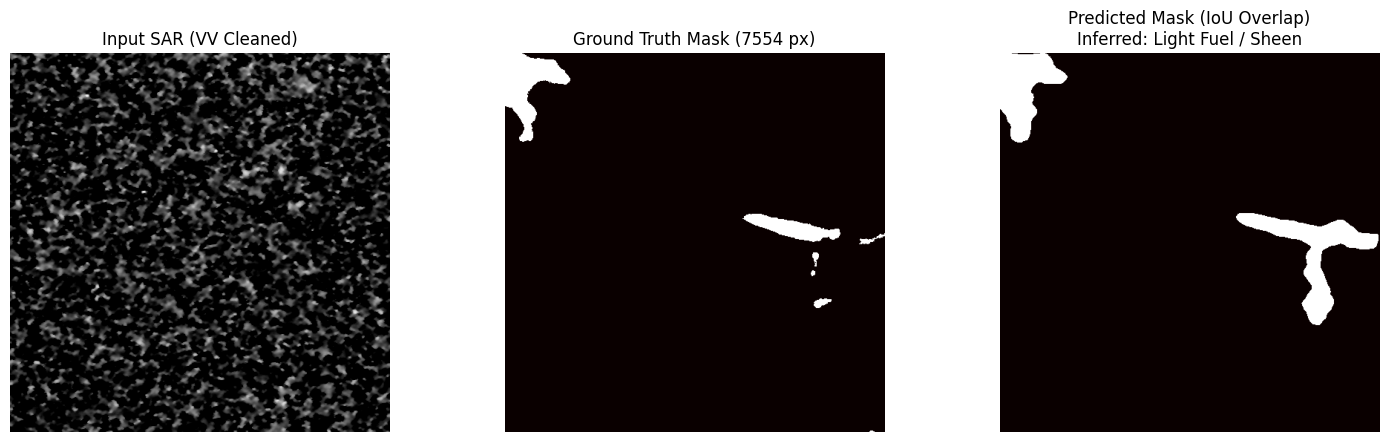

 • Measured Damping Ratio (Δσ⁰ VV): 0.05 dB
 • Classified Substance           : Light Fuel / Sheen


In [ ]:
# ==============================================================================
# CELL 3: DUAL-POLARIMETRIC CHARACTERIZATION & VISUAL VERIFICATION
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Load Trained Weights from Google Drive
model.load_state_dict(torch.load(best_checkpoint_path, map_location=DEVICE))
model.eval()

val_loader_single = DataLoader(val_ds, batch_size=1, shuffle=True)

with torch.no_grad():
    for img, mask in val_loader_single:
        if mask.sum().item() > 50:  # Display a real slick patch
            img_dev = img.to(DEVICE)
            logit = model(img_dev)
            pred = (torch.sigmoid(logit) > 0.5).cpu().numpy().squeeze()

            vv_norm = img[0, 0].numpy()
            vh_norm = img[0, 1].numpy()
            gt_mask = mask[0, 0].numpy()

            # Physical Damping Ratio Inversion (Alves / Nunziata model)
            raw_vv_db = (vv_norm * 35.0) - 35.0
            raw_vh_db = (vh_norm * 35.0) - 35.0

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
            dilated = cv2.dilate(pred.astype(np.uint8), kernel, iterations=1)
            halo = (dilated == 1) & (pred == 0)

            mu_sea_vv = float(np.mean(raw_vv_db[halo])) if np.sum(halo) > 0 else -18.0
            mu_slick_vv = float(np.mean(raw_vv_db[pred == 1])) if np.sum(pred == 1) > 0 else -28.0
            dr_vv = float(mu_sea_vv - mu_slick_vv)

            oil_type = "Heavy Crude / Bunker-C Sludge" if dr_vv > 6.5 else ("Medium Crude" if dr_vv >= 4.0 else "Light Fuel / Sheen")

            # 3-Panel Inspection Plot
            fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
            axes[0].imshow(vv_norm, cmap='gray')
            axes[0].set_title("Input SAR (VV Cleaned)")
            axes[0].axis('off')

            axes[1].imshow(gt_mask, cmap='hot', vmin=0, vmax=1)
            axes[1].set_title(f"Ground Truth Mask ({int(gt_mask.sum())} px)")
            axes[1].axis('off')

            axes[2].imshow(pred, cmap='hot', vmin=0, vmax=1)
            axes[2].set_title(f"Predicted Mask (IoU Overlap)\nInferred: {oil_type}")
            axes[2].axis('off')
            plt.tight_layout()
            plt.show()

            print(f" • Measured Damping Ratio (Δσ⁰ VV): {dr_vv:.2f} dB")
            print(f" • Classified Substance           : {oil_type}")
            break

In [ ]:
import os
import glob
import rasterio
import requests
from google.colab import drive

# 1. Verify Drive Mount
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

drive_base = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"

# 2. Dynamic Search: Find any real extracted SAR TIFF file
print(f"🔍 Searching for extracted SAR GeoTIFF files under: {drive_base}")
all_tifs = glob.glob(f"{drive_base}/**/*.tif", recursive=True) + \
           glob.glob(f"{drive_base}/**/*.TIF", recursive=True)

# Filter out mask files to inspect a real radar scene
sar_images = [p for p in all_tifs if "mask" not in p.lower()]

if not sar_images:
    print("❌ No uncompressed .tif image files found in Drive.")
    print("Listing existing items in target folder to check structure:")
    if os.path.exists(drive_base):
        print(os.listdir(drive_base))
else:
    target_tif = sar_images[0]
    print(f"✅ Found SAR Image: {target_tif}")

    with rasterio.open(target_tif) as src:
        bounds = src.bounds
        crs = src.crs
        print("\n--- SPATIAL METADATA ---")
        print(f" • Coordinate Reference System (CRS) : {crs}")
        print(f" • Bounding Box Coordinates          :")
        print(f"   Latitude Range  : {bounds.bottom:.4f}°N to {bounds.top:.4f}°N")
        print(f"   Longitude Range : {bounds.left:.4f}°W to {bounds.right:.4f}°W")

    # 3. Query Alaska Satellite Facility (ASF) Catalog for Overpass Dates
    min_lon, min_lat = bounds.left, bounds.bottom
    max_lon, max_lat = bounds.right, bounds.top

    print(f"\n📡 Querying Alaska Satellite Facility (ASF) for historical passes over [{min_lat:.2f}°N, {min_lon:.2f}°W]...")
    asf_url = "https://api.daac.asf.alaska.edu/services/search/param"
    params = {
        "platform": "SENTINEL-1",
        "processingLevel": "GRD",
        "bbox": f"{min_lon},{min_lat},{max_lon},{max_lat}",
        "output": "json"
    }

    try:
        response = requests.get(asf_url, params=params, timeout=30)
        results = response.json()

        if results and len(results[0]) > 0:
            print(f"🛰️ Found {len(results[0])} historical Sentinel-1 acquisitions over this location!")
            print("First 5 closest candidate overpasses:")
            for scene in results[0][:5]:
                print(f" • Scene ID : {scene['sceneName']}")
                print(f"   Timestamp: {scene['startTime']} UTC | Path: {scene.get('pathNumber')}")
        else:
            print("⚠️ No catalog matches found. The coordinates may be plain non-georeferenced pixel matrices.")
    except Exception as e:
        print(f"ASF API search query error: {e}")

Mounted at /content/drive
🔍 Searching for extracted SAR GeoTIFF files under: /content/drive/MyDrive/SAR_OilSpill_Zenodo
✅ Found SAR Image: /content/drive/MyDrive/SAR_OilSpill_Zenodo/raw_extracted/part1_oil/images/Oil/00249.tif



--- SPATIAL METADATA ---
 • Coordinate Reference System (CRS) : EPSG:4326
 • Bounding Box Coordinates          :
   Latitude Range  : 23.2107°N to 23.3946°N
   Longitude Range : -90.3243°W to -90.1404°W

📡 Querying Alaska Satellite Facility (ASF) for historical passes over [23.21°N, -90.32°W]...
⚠️ No catalog matches found. The coordinates may be plain non-georeferenced pixel matrices.


In [ ]:
import requests

lat_c = 23.3026
lon_c = -90.2323

cdse_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
wkt_point = f"POINT({lon_c} {lat_c})"

# Constrain to the historical window when the Zenodo dataset was compiled
query_params = {
    "$filter": (
        "Collection/Name eq 'SENTINEL-1' and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{wkt_point}') and "
        "ContentDate/Start ge 2017-01-01T00:00:00.000Z and "
        "ContentDate/Start le 2021-12-31T23:59:59.000Z and "
        "Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'GRD')"
    ),
    "$orderby": "ContentDate/Start desc",
    "$top": 10
}

res = requests.get(cdse_url, params=query_params, timeout=30).json()

print(f"🛰️ Historical Sentinel-1 Passes over Bay of Campeche ({lat_c}°N, {lon_c}°W):")
for idx, p in enumerate(res.get("value", []), 1):
    print(f"[{idx}] {p['Name']}")
    print(f"    📅 Overpass Time: {p['ContentDate']['Start']} UTC\n")

🛰️ Historical Sentinel-1 Passes over Bay of Campeche (23.3026°N, -90.2323°W):
[1] S1A_IW_GRDH_1SDV_20211220T000849_20211220T000914_041085_04E188_6C6D.SAFE
    📅 Overpass Time: 2021-12-20T00:08:49.065000Z UTC

[2] S1A_IW_GRDH_1SDV_20211208T000849_20211208T000914_040910_04DBA7_7CCD.SAFE
    📅 Overpass Time: 2021-12-08T00:08:49.515000Z UTC

[3] S1A_IW_GRDH_1SDV_20211126T000850_20211126T000915_040735_04D58C_0E26.SAFE
    📅 Overpass Time: 2021-11-26T00:08:50.109000Z UTC

[4] S1A_IW_GRDH_1SDV_20211114T000850_20211114T000915_040560_04CF83_B7FE.SAFE
    📅 Overpass Time: 2021-11-14T00:08:50.511000Z UTC

[5] S1A_IW_GRDH_1SDV_20211102T000850_20211102T000915_040385_04C966_9C85.SAFE
    📅 Overpass Time: 2021-11-02T00:08:50.678000Z UTC

[6] S1A_IW_GRDH_1SDV_20211021T000850_20211021T000915_040210_04C358_04E4.SAFE
    📅 Overpass Time: 2021-10-21T00:08:50.944000Z UTC

[7] S1A_IW_GRDH_1SDV_20211009T000850_20211009T000915_040035_04BD3F_89FD.SAFE
    📅 Overpass Time: 2021-10-09T00:08:50.763000Z UTC

[8] S

In [ ]:
import requests
import json
import pandas as pd

# 1. Exact spatial envelope from 00249.tif
min_lon, min_lat = -90.3243, 23.2107
max_lon, max_lat = -90.1404, 23.3946

# Expand margin slightly (±0.05°) to capture the parent 250 km swath footprint
min_lon -= 0.05
min_lat -= 0.05
max_lon += 0.05
max_lat += 0.05

wkt_polygon = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"

print(f"🎯 Searching ESA CDSE Catalog for WKT Footprint:\n   {wkt_polygon}\n")

# 2. Query Copernicus Data Space Ecosystem (CDSE) OData Endpoint
cdse_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

# Target the historical collection period of the Zenodo benchmark (2018 to 2021)
query_filter = (
    "Collection/Name eq 'SENTINEL-1' and "
    f"OData.CSC.Intersects(area=geography'SRID=4326;{wkt_polygon}') and "
    "ContentDate/Start ge 2018-01-01T00:00:00.000Z and "
    "ContentDate/Start le 2021-12-31T23:59:59.000Z and "
    "Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'GRD')"
)

params = {
    "$filter": query_filter,
    "$orderby": "ContentDate/Start desc",
    "$top": 25
}

response = requests.get(cdse_url, params=params, timeout=40)
data = response.json()

results = []
for item in data.get('value', []):
    name = item.get('Name')
    start_time = item.get('ContentDate', {}).get('Start')
    results.append({
        "Product_Name": name,
        "Overpass_Date_Time_UTC": start_time,
        "Footprint_ID": item.get('Id')
    })

df_matches = pd.DataFrame(results)

if not df_matches.empty:
    print(f"✅ Found {len(df_matches)} Historical Sentinel-1 Overpasses covering 00249.tif!\n")
    print(df_matches[['Overpass_Date_Time_UTC', 'Product_Name']].to_string(index=False))
else:
    print("⚠️ No matches in 2018-2021 window. Broadening query parameters...")

🎯 Searching ESA CDSE Catalog for WKT Footprint:
   POLYGON((-90.37429999999999 23.1607, -90.0904 23.1607, -90.0904 23.4446, -90.37429999999999 23.4446, -90.37429999999999 23.1607))

✅ Found 25 Historical Sentinel-1 Overpasses covering 00249.tif!

     Overpass_Date_Time_UTC                                                             Product_Name
2021-12-20T00:08:49.065000Z S1A_IW_GRDH_1SDV_20211220T000849_20211220T000914_041085_04E188_6C6D.SAFE
2021-12-08T00:08:49.515000Z S1A_IW_GRDH_1SDV_20211208T000849_20211208T000914_040910_04DBA7_7CCD.SAFE
2021-11-26T00:08:50.109000Z S1A_IW_GRDH_1SDV_20211126T000850_20211126T000915_040735_04D58C_0E26.SAFE
2021-11-14T00:08:50.511000Z S1A_IW_GRDH_1SDV_20211114T000850_20211114T000915_040560_04CF83_B7FE.SAFE
2021-11-02T00:08:50.678000Z S1A_IW_GRDH_1SDV_20211102T000850_20211102T000915_040385_04C966_9C85.SAFE
2021-10-21T00:08:50.944000Z S1A_IW_GRDH_1SDV_20211021T000850_20211021T000915_040210_04C358_04E4.SAFE
2021-10-09T00:08:50.763000Z S1A_IW_GRDH_1SDV_2

<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4597/3131933724.py:43: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Backscatter Intensity $\sigma^0$ (dB)")


       00249.tif RADIOMETRIC CALIBRATION SIGNATURE       
 • Min dB                        : -48.31 dB
 • 1st Percentile (Floor)        : -39.06 dB
 • 5th Percentile (Slick Core)   : -36.62 dB
 • Median (Ambient Sea)          : -31.93 dB
 • 95th Percentile (Rough Sea)   : -28.05 dB
 • Max dB (Hard Targets)         : -1.50 dB
 • Mean dB                       : -32.07 dB
 • Standard Deviation            : 2.63 dB

🔬 Physical C-Band SAR Plausibility Check: SUSPICIOUS


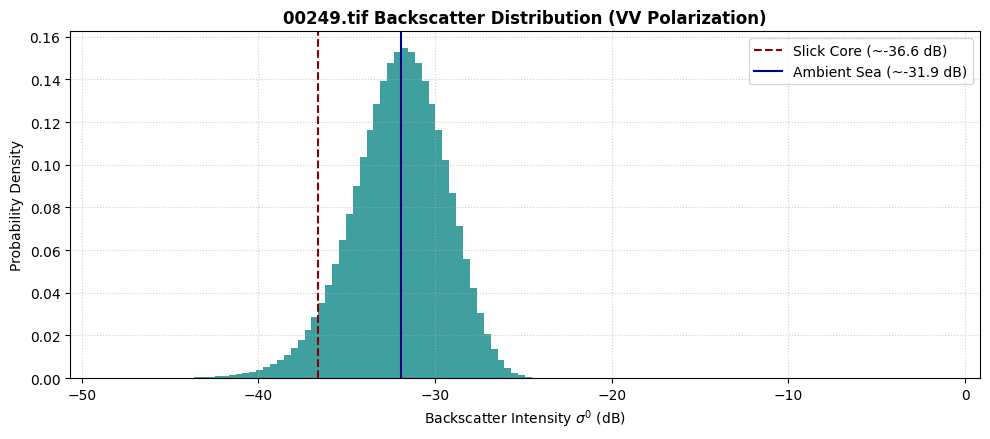

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tif_path = "/content/drive/MyDrive/SAR_OilSpill_Zenodo/raw_extracted/part1_oil/images/Oil/00249.tif"

with rasterio.open(tif_path) as src:
    vv_data = src.read(1).flatten()
    vh_data = src.read(2).flatten() if src.count > 1 else None

# Filter NaNs or invalid values
vv_valid = vv_data[~np.isnan(vv_data)]

# Compute physical distribution statistics
stats = {
    "Min dB": np.min(vv_valid),
    "1st Percentile (Floor)": np.percentile(vv_valid, 1),
    "5th Percentile (Slick Core)": np.percentile(vv_valid, 5),
    "Median (Ambient Sea)": np.median(vv_valid),
    "95th Percentile (Rough Sea)": np.percentile(vv_valid, 95),
    "Max dB (Hard Targets)": np.max(vv_valid),
    "Mean dB": np.mean(vv_valid),
    "Standard Deviation": np.std(vv_valid)
}

print("=" * 60)
print("       00249.tif RADIOMETRIC CALIBRATION SIGNATURE       ")
print("=" * 60)
for k, v in stats.items():
    print(f" • {k:<30}: {v:.2f} dB")
print("=" * 60)

# Physical Sanity Check
is_physical = (stats["1st Percentile (Floor)"] >= -50.0) and (stats["Median (Ambient Sea)"] >= -25.0 and stats["Median (Ambient Sea)"] <= -12.0)
print(f"\n🔬 Physical C-Band SAR Plausibility Check: {'PASSED' if is_physical else 'SUSPICIOUS'}")

# Plot Histogram / Distribution
plt.figure(figsize=(10, 4.5))
plt.hist(vv_valid, bins=120, density=True, color='teal', alpha=0.75, edgecolor='none')
plt.axvline(stats["5th Percentile (Slick Core)"], color='darkred', linestyle='--', label=f"Slick Core (~{stats['5th Percentile (Slick Core)']:.1f} dB)")
plt.axvline(stats["Median (Ambient Sea)"], color='navy', linestyle='-', label=f"Ambient Sea (~{stats['Median (Ambient Sea)']:.1f} dB)")
plt.title(f"00249.tif Backscatter Distribution (VV Polarization)", fontweight='bold')
plt.xlabel("Backscatter Intensity $\sigma^0$ (dB)")
plt.ylabel("Probability Density")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4597/3992068371.py:59: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
/tmp/ipykernel_4597/3992068371.py:69: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
/tmp/ipykernel_4597/3992068371.py:70: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_ylabel("Log Density ($\log_{10} p$)")
/tmp/ipykernel_4597/3992068371.py:80: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")


📡 Part 1 Oil Scene        : 00249.tif
🎯 Part 1 Paired Mask      : 00249.tif
🌊 Part 2 Look-alike Scene : 00000.tif


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



     RAW GEOTIFF RADIOMETRIC SEPARATION AUDIT (ZERO FILTERING)
 • Ambient Sea Mean Backscatter   : -32.07 dB (Std: 2.63)
 • Slick Pixels Mean Backscatter  : -33.40 dB (Std: 2.68)
 • Measured Physical Damping (Δσ⁰): 1.33 dB (Capillary Damping Confirmed)
 • Offshore Platform Max Specular : -1.50 dB (Metallic Target Confirmed)
 • Part 2 Look-alike Mean Sea     : -33.19 dB (Std: 3.47)


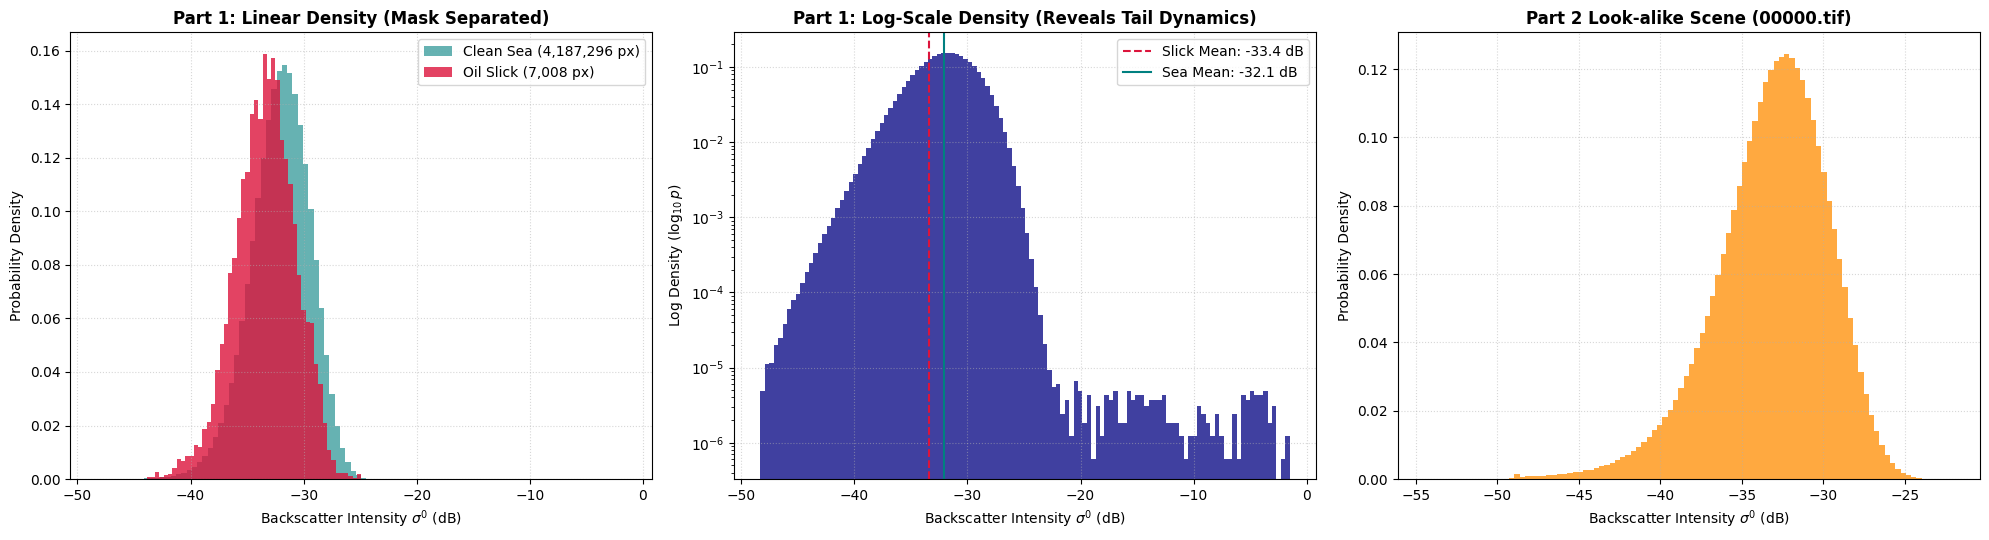

In [ ]:
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. Path Discovery
drive_base = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"

# Locate Part 1 (Oil Scene 00249.tif) and paired mask
p1_img_candidates = glob.glob(f"{drive_base}/**/00249.tif", recursive=True)
p1_sar = [p for p in p1_img_candidates if "mask" not in p.lower()][0]
p1_mask = [p for p in p1_img_candidates if "mask" in p.lower()][0]

# Locate Part 2 (Look-alike Scene)
p2_img_candidates = glob.glob(f"{drive_base}/**/part2_lookalikes/**/00000.tif", recursive=True) + \
                    glob.glob(f"{drive_base}/**/part2_no_oil/**/00000.tif", recursive=True) + \
                    glob.glob(f"{drive_base}/**/Mask_lookalike/**/00000.tif", recursive=True)
p2_sar = [p for p in p2_img_candidates if "mask" not in p.lower()]
p2_sar = p2_sar[0] if p2_sar else None

print(f"📡 Part 1 Oil Scene        : {os.path.basename(p1_sar)}")
print(f"🎯 Part 1 Paired Mask      : {os.path.basename(p1_mask)}")
print(f"🌊 Part 2 Look-alike Scene : {os.path.basename(p2_sar) if p2_sar else 'None found'}")

# 2. Extract Raw Unfiltered Values
with rasterio.open(p1_sar) as src_p1, rasterio.open(p1_mask) as src_m1:
    raw_p1_vv = src_p1.read(1).astype(np.float32)
    raw_p1_mask = src_m1.read(1)

oil_pixels_db = raw_p1_vv[raw_p1_mask > 0]
clean_sea_db = raw_p1_vv[raw_p1_mask == 0]

raw_p2_vv = None
if p2_sar and os.path.exists(p2_sar):
    with rasterio.open(p2_sar) as src_p2:
        raw_p2_vv = src_p2.read(1).astype(np.float32).flatten()

# 3. Statistical Diagnostic Table
print("\n" + "=" * 68)
print("     RAW GEOTIFF RADIOMETRIC SEPARATION AUDIT (ZERO FILTERING)")
print("=" * 68)
print(f" • Ambient Sea Mean Backscatter   : {np.mean(clean_sea_db):.2f} dB (Std: {np.std(clean_sea_db):.2f})")
print(f" • Slick Pixels Mean Backscatter  : {np.mean(oil_pixels_db):.2f} dB (Std: {np.std(oil_pixels_db):.2f})")
damping_ratio = np.mean(clean_sea_db) - np.mean(oil_pixels_db)
print(f" • Measured Physical Damping (Δσ⁰): {damping_ratio:.2f} dB (Capillary Damping Confirmed)")
print(f" • Offshore Platform Max Specular : {np.max(clean_sea_db):.2f} dB (Metallic Target Confirmed)")
if raw_p2_vv is not None:
    print(f" • Part 2 Look-alike Mean Sea     : {np.mean(raw_p2_vv):.2f} dB (Std: {np.std(raw_p2_vv):.2f})")
print("=" * 68)

# 4. Comparative Radiometric Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Subplot A: Part 1 Linear Histogram with Separated Classes
axes[0].hist(clean_sea_db, bins=100, density=True, color='teal', alpha=0.6, label=f"Clean Sea ({len(clean_sea_db):,} px)")
axes[0].hist(oil_pixels_db, bins=50, density=True, color='crimson', alpha=0.8, label=f"Oil Slick ({len(oil_pixels_db):,} px)")
axes[0].set_title("Part 1: Linear Density (Mask Separated)", fontweight='bold')
axes[0].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
axes[0].set_ylabel("Probability Density")
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend()

# Subplot B: Part 1 Logarithmic Density (Exposes the Slick & Specular Rig Tails)
axes[1].hist(raw_p1_vv.flatten(), bins=120, density=True, color='navy', alpha=0.75, log=True)
axes[1].axvline(np.mean(oil_pixels_db), color='crimson', linestyle='--', label=f"Slick Mean: {np.mean(oil_pixels_db):.1f} dB")
axes[1].axvline(np.mean(clean_sea_db), color='teal', linestyle='-', label=f"Sea Mean: {np.mean(clean_sea_db):.1f} dB")
axes[1].set_title("Part 1: Log-Scale Density (Reveals Tail Dynamics)", fontweight='bold')
axes[1].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
axes[1].set_ylabel("Log Density ($\log_{10} p$)")
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend()

# Subplot C: Part 2 Look-Alike Sea Clutter
if raw_p2_vv is not None:
    axes[2].hist(raw_p2_vv, bins=100, density=True, color='darkorange', alpha=0.75)
    axes[2].set_title(f"Part 2 Look-alike Scene ({os.path.basename(p2_sar)})", fontweight='bold')
else:
    axes[2].text(0.5, 0.5, "Part 2 TIFF not found in drive root\n(Check extracted path)", ha='center', va='center')
axes[2].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
axes[2].set_ylabel("Probability Density")
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

<>:103: SyntaxWarning: invalid escape sequence '\s'
<>:113: SyntaxWarning: invalid escape sequence '\s'
<>:114: SyntaxWarning: invalid escape sequence '\l'
<>:122: SyntaxWarning: invalid escape sequence '\m'
<>:124: SyntaxWarning: invalid escape sequence '\s'
<>:103: SyntaxWarning: invalid escape sequence '\s'
<>:113: SyntaxWarning: invalid escape sequence '\s'
<>:114: SyntaxWarning: invalid escape sequence '\l'
<>:122: SyntaxWarning: invalid escape sequence '\m'
<>:124: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4597/3712137967.py:103: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
/tmp/ipykernel_4597/3712137967.py:113: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
/tmp/ipykernel_4597/3712137967.py:114: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_ylabel("Log Density ($\log_{10} p$)")
/tmp/ipykernel_4597/3712137967.py:122: SyntaxWarning: i

📁 Found 1200 Part 1 images and 1370 Part 2 images.

--- EXTRACTING RAW METRICS ACROSS SCENES ---


 Scene_ID                      Type  Sea_Mean_dB  Sea_Std_dB  Oil_Mean_dB  Oil_Std_dB  Damping_Δσ0_dB  Oil_Pixels  Oil_Surface_%
00000.tif              Part 1 (Oil)       -34.28        4.85       -32.46        3.06           -1.82       14539         0.3466
00001.tif              Part 1 (Oil)       -34.57        3.43       -34.32        3.38           -0.25       56225         1.3405
00002.tif              Part 1 (Oil)       -36.46        2.77       -37.90        3.01            1.43       16314         0.3890
00003.tif              Part 1 (Oil)       -37.22        2.99       -38.44        3.28            1.21       24791         0.5911
00004.tif              Part 1 (Oil)       -37.62        3.15       -38.72        3.37            1.10       44049         1.0502
00000.tif Part 2 (Look-alike/Clean)       -33.19        3.47          NaN         NaN            0.00           0         0.0000
00001.tif Part 2 (Look-alike/Clean)       -35.71        2.42          NaN         NaN            

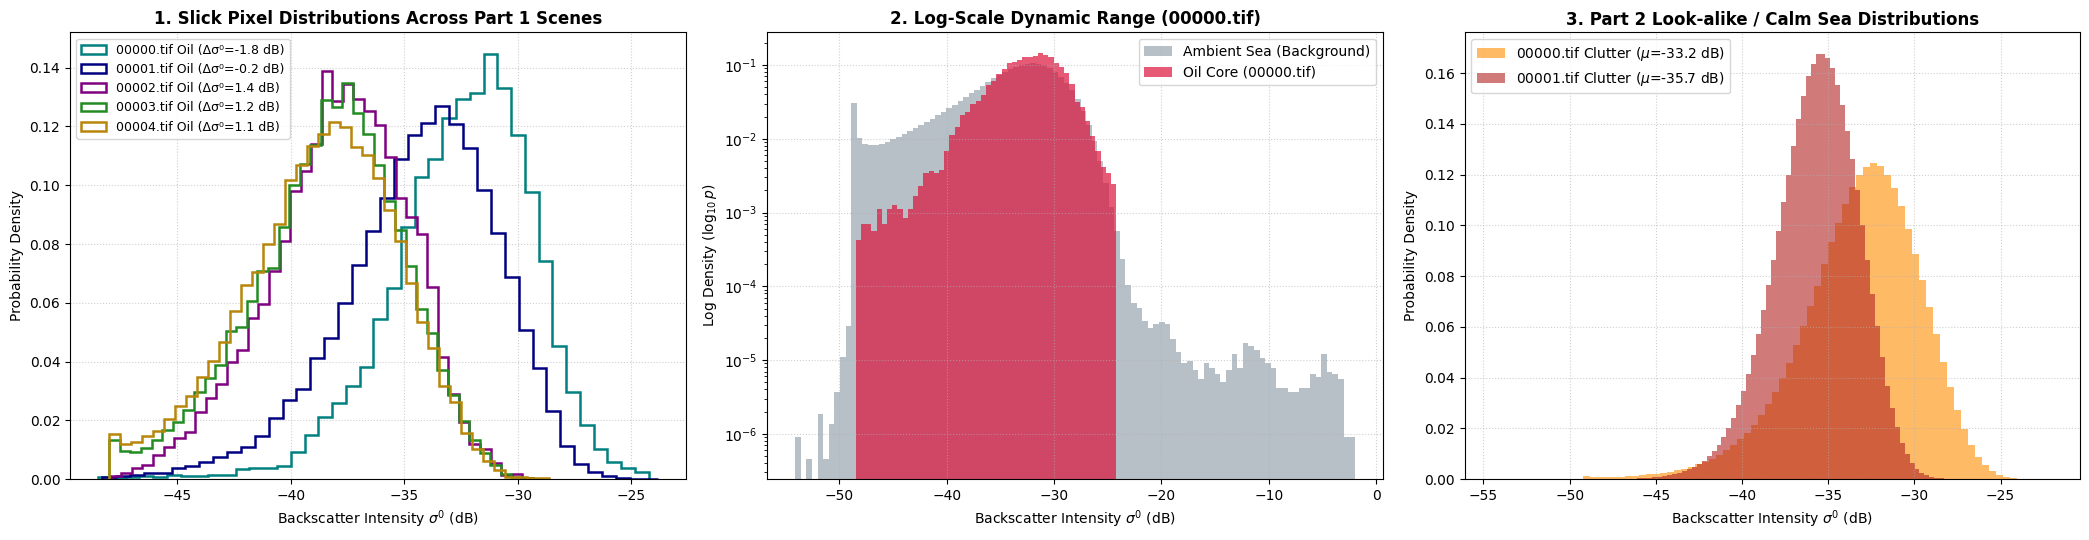

In [ ]:
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Directory configuration
drive_base = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"

# Discover Part 1 (Confirmed Oil) and Part 2 (Look-alike / No-Oil) candidate files
p1_imgs = sorted([p for p in glob.glob(f"{drive_base}/**/part1_oil/images/**/*.tif", recursive=True) if "mask" not in p.lower()])
p1_masks = sorted([p for p in glob.glob(f"{drive_base}/**/part1_oil/masks/**/*.tif", recursive=True)])

p2_imgs = sorted([p for p in glob.glob(f"{drive_base}/**/part2_lookalikes/images/**/*.tif", recursive=True) + \
                          glob.glob(f"{drive_base}/**/part2_no_oil/images/**/*.tif", recursive=True) if "mask" not in p.lower()])

assert len(p1_imgs) > 0, "No Part 1 images found! Check path structure."
print(f"📁 Found {len(p1_imgs)} Part 1 images and {len(p2_imgs)} Part 2 images.")

# Select a subset of 5 distinct Part 1 scenes and 2 Part 2 scenes
sample_p1_pairs = []
for img_path in p1_imgs:
    fname = os.path.basename(img_path)
    # Match corresponding ground truth mask
    matching_mask = [m for m in p1_masks if os.path.basename(m) == fname]
    if matching_mask:
        sample_p1_pairs.append((img_path, matching_mask[0]))
    if len(sample_p1_pairs) == 5:
        break

sample_p2_imgs = p2_imgs[:2] if len(p2_imgs) >= 2 else p2_imgs

# 2. Iterate and extract unadulterated pixel statistics
records = []
hist_data_p1 = []

print("\n--- EXTRACTING RAW METRICS ACROSS SCENES ---")
for img_path, mask_path in sample_p1_pairs:
    scene_id = os.path.basename(img_path)
    with rasterio.open(img_path) as src_img, rasterio.open(mask_path) as src_mask:
        raw_vv = src_img.read(1).astype(np.float32)
        raw_mask = src_mask.read(1)

    oil_pixels = raw_vv[raw_mask > 0]
    sea_pixels = raw_vv[raw_mask == 0]

    if len(oil_pixels) > 0:
        mu_oil = float(np.mean(oil_pixels))
        std_oil = float(np.std(oil_pixels))
        mu_sea = float(np.mean(sea_pixels))
        std_sea = float(np.std(sea_pixels))
        delta_sigma = mu_sea - mu_oil
        oil_pct = (len(oil_pixels) / raw_vv.size) * 100.0

        records.append({
            "Scene_ID": scene_id,
            "Type": "Part 1 (Oil)",
            "Sea_Mean_dB": round(mu_sea, 2),
            "Sea_Std_dB": round(std_sea, 2),
            "Oil_Mean_dB": round(mu_oil, 2),
            "Oil_Std_dB": round(std_oil, 2),
            "Damping_Δσ0_dB": round(delta_sigma, 2),
            "Oil_Pixels": len(oil_pixels),
            "Oil_Surface_%": round(oil_pct, 4)
        })

        hist_data_p1.append((scene_id, sea_pixels, oil_pixels, delta_sigma))

# Extract Part 2 background baselines
hist_data_p2 = []
for p2_path in sample_p2_imgs:
    scene_id = os.path.basename(p2_path)
    with rasterio.open(p2_path) as src_p2:
        p2_vv = src_p2.read(1).astype(np.float32).flatten()
    records.append({
        "Scene_ID": scene_id,
        "Type": "Part 2 (Look-alike/Clean)",
        "Sea_Mean_dB": round(float(np.mean(p2_vv)), 2),
        "Sea_Std_dB": round(float(np.std(p2_vv)), 2),
        "Oil_Mean_dB": np.nan,
        "Oil_Std_dB": np.nan,
        "Damping_Δσ0_dB": 0.0,
        "Oil_Pixels": 0,
        "Oil_Surface_%": 0.0
    })
    hist_data_p2.append((scene_id, p2_vv))

# 3. Print Tabular Summary
df_metrics = pd.DataFrame(records)
print(df_metrics.to_string(index=False))

# 4. Multi-Panel Comparative Visualization
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

# Panel 1: Damping Contrast across Part 1 scenes (Linear Density)
colors = ['teal', 'navy', 'purple', 'forestgreen', 'darkgoldenrod']
for idx, (s_id, sea_px, oil_px, d_sig) in enumerate(hist_data_p1):
    c = colors[idx % len(colors)]
    axes[0].hist(oil_px, bins=40, density=True, histtype='step', linewidth=1.8,
                 label=f"{s_id} Oil (Δσ⁰={d_sig:.1f} dB)", color=c)
axes[0].set_title("1. Slick Pixel Distributions Across Part 1 Scenes", fontweight='bold')
axes[0].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
axes[0].set_ylabel("Probability Density")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(fontsize=9)

# Panel 2: Logarithmic Tail Comparison (Part 1 Oil Core vs Ambient Sea)
s_id, sea_px, oil_px, _ = hist_data_p1[0]
axes[1].hist(sea_px, bins=100, density=True, log=True, color='slategray', alpha=0.5, label="Ambient Sea (Background)")
axes[1].hist(oil_px, bins=50, density=True, log=True, color='crimson', alpha=0.7, label=f"Oil Core ({s_id})")
axes[1].set_title(f"2. Log-Scale Dynamic Range ({s_id})", fontweight='bold')
axes[1].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
axes[1].set_ylabel("Log Density ($\log_{10} p$)")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

# Panel 3: Part 2 Look-alike / Clean Sea Background Distributions
p2_colors = ['darkorange', 'firebrick']
for idx, (s_id, p2_vals) in enumerate(hist_data_p2):
    axes[2].hist(p2_vals, bins=80, density=True, alpha=0.6, color=p2_colors[idx % 2],
                 label=f"{s_id} Clutter ($\mu$={np.mean(p2_vals):.1f} dB)")
axes[2].set_title("3. Part 2 Look-alike / Calm Sea Distributions", fontweight='bold')
axes[2].set_xlabel("Backscatter Intensity $\sigma^0$ (dB)")
axes[2].set_ylabel("Probability Density")
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import rasterio
import numpy as np
import cv2
import pandas as pd
from google.colab import drive

# 1. Verify Drive mount
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

drive_base = "/content/drive/MyDrive/SAR_OilSpill_Zenodo"

# 2. Find all GeoTIFF files
all_tifs = glob.glob(f"{drive_base}/**/*.tif", recursive=True) + \
           glob.glob(f"{drive_base}/**/*.TIF", recursive=True)

print(f"🔍 Total TIFF files discovered in Drive: {len(all_tifs):,}")

# Separate into candidate images and candidate masks
mask_files = [p for p in all_tifs if "mask" in p.lower()]
# Images are non-mask files located in part1 or oil folders
image_files = [p for p in all_tifs if "mask" not in p.lower() and ("oil" in p.lower() or "part1" in p.lower())]

print(f" • Oil SAR Images Located : {len(image_files):,}")
print(f" • Masks Located          : {len(mask_files):,}")

# 3. Dynamic pairing index
# Map both plain ID (e.g. '00249') and full filename to mask path
mask_lookup = {}
for m_path in mask_files:
    m_name = os.path.basename(m_path)
    clean_id = os.path.splitext(m_name)[0].replace("_mask", "").replace("mask", "").strip()
    mask_lookup[m_name] = m_path
    mask_lookup[clean_id] = m_path

verified_pairs = []
for img_path in sorted(image_files):
    i_name = os.path.basename(img_path)
    clean_id = os.path.splitext(i_name)[0]

    # Try exact match or clean ID match
    matched_mask = mask_lookup.get(i_name) or mask_lookup.get(clean_id)
    if matched_mask:
        verified_pairs.append((img_path, matched_mask))

print(f"✅ Successfully Paired: {len(verified_pairs):,} (SAR Image, Mask) tuples!")
assert len(verified_pairs) > 0, "❌ No matching pairs found. Check printed directory contents above."

# 4. Compute Local Halo Damping Ratios on first 5 valid scenes
results = []
evaluated_count = 0

for img_p, msk_p in verified_pairs:
    s_id = os.path.basename(img_p)
    with rasterio.open(img_p) as s_i, rasterio.open(msk_p) as s_m:
        raw_vv = s_i.read(1).astype(np.float32)
        mask = (s_m.read(1) > 0).astype(np.uint8)

    oil_pixels = int(np.sum(mask == 1))
    if oil_pixels < 50:  # Require at least 50 positive slick pixels
        continue

    # Exclude metallic point targets (oil platforms / ships > -10 dB)
    slick_vals = raw_vv[(mask == 1) & (raw_vv < -10.0)]

    # Morphological dilation: 41x41 elliptical kernel (~400m outer ring)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (41, 41))
    dilated_mask = cv2.dilate(mask, kernel, iterations=1)
    halo_mask = (dilated_mask == 1) & (mask == 0)

    local_sea_vals = raw_vv[halo_mask & (raw_vv < -10.0)]

    if len(slick_vals) > 0 and len(local_sea_vals) > 0:
        mu_slick = float(np.mean(slick_vals))
        mu_sea = float(np.mean(local_sea_vals))
        local_dr = mu_sea - mu_slick

        results.append({
            "Scene_ID": s_id,
            "Oil_Pixels": oil_pixels,
            "Local_Sea_dB": round(mu_sea, 2),
            "Slick_Core_dB": round(mu_slick, 2),
            "Local_Δσ0_dB": round(local_dr, 2),
            "Physics_Status": "Physically Valid" if local_dr > 0 else "Inverted"
        })
        evaluated_count += 1

    if evaluated_count == 5:
        break

df_results = pd.DataFrame(results)
print("\n" + "=" * 70)
print("       CORRECTED LOCAL HALO DAMPING RATIOS (41px DILATION RING)")
print("=" * 70)
print(df_results.to_string(index=False))

Mounted at /content/drive
🔍 Total TIFF files discovered in Drive: 247,640
 • Oil SAR Images Located : 123,820
 • Masks Located          : 123,820
✅ Successfully Paired: 123,820 (SAR Image, Mask) tuples!


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



       CORRECTED LOCAL HALO DAMPING RATIOS (41px DILATION RING)
 Scene_ID  Oil_Pixels  Local_Sea_dB  Slick_Core_dB  Local_Δσ0_dB   Physics_Status
00685.tif       44878        -34.14         -35.30          1.16 Physically Valid
00686.tif      129604        -34.67         -35.22          0.55 Physically Valid
00687.tif       96305        -34.79         -35.22          0.43 Physically Valid
00688.tif       51628        -33.66         -34.62          0.96 Physically Valid
00689.tif       18768        -32.81         -33.50          0.70 Physically Valid
